# SPC722P - AI in Astrophysics and Space Science
## Final project

## Due on Sunday, 17th May 2026, 11:59 PM
## Please name your file as LAST_NAME_Final_project.ipynb and upload it on QMPlus (Assessment tab)

The **Van Allen Probes**, launched by NASA in 2012, were designed to investigate the dynamics of Earth's radiation belts, which consist of highly energetic charged particles trapped by the planet's magnetic field. These probes provided high-resolution measurements of the radiation belt environment, significantly improving our understanding of how particles are accelerated, transported, and lost due to various physical processes. Equipped with state-of-the-art instruments, the Van Allen Probes collected data on electric and magnetic fields, plasma waves, and energetic particles, enabling researchers to explore the complex interplay between wave-particle interactions and large-scale transport mechanisms. The mission concluded in 2019, but its data continue to be a valuable resource for studying space weather and magnetospheric physics.  

One fundamental process governing the evolution of radiation belt electrons is **radial diffusion**, which describes the transport of energetic particles across magnetic field lines due to fluctuating electric and magnetic fields. This mechanism is particularly important for understanding how electrons move outward or inward in response to large-scale variations in the geomagnetic field. Radial diffusion can be driven by interactions with ultra-low-frequency (ULF) waves, which lead to stochastic changes in a particle’s radial position while approximately conserving its first two adiabatic invariants. This process is often modeled using a diffusion equation, where the diffusion coefficient characterizes the rate at which particles spread in radial distance. By leveraging Van Allen Probes data, researchers have been able to refine radial diffusion models, improve estimates of diffusion coefficients, and assess the role of this mechanism in driving radiation belt dynamics during geomagnetic storms and other space weather events.

The characterization of transport coefficients still constitutes an open research area in the study of the Earth's radiation belt.

In this project you will use real data from the Van Allen Probes satellite to derive the diffusion coefficient of the following equation:

\begin{equation}
\frac{\partial u(x,t)}{\partial t} =  \frac{\partial}{\partial x}\left(D(x) \frac{\partial u(x,t)}{\partial x} \right) 
\end{equation}

where $u(x,t)$ is the phase space density (function of space $x$ and time $t$) and $D(x)$ is the diffusion coefficient. For simplicity, we will assume that $D$ is time-independent (i.e., only function of $x$).

## Task 

1) Load the dataset 'Data_final_project.csv' (in the data folder). The dataset has three columns: Time (t), Space (x), and PSD (Phase Space Density). PSD is the variable $u$ in the above equation. The data has been pre-processed and interpolated on a uniform grid (the original data is unstructured, since it is located on the satellites trajectories).
2) The data is defined on a grid of size (X,T) = (50,2000). Because the Time variable cannot directly be used in a neural network, define an auxiliary variable T_train in units of days.
3) The task is to estimate $D(x)$ using a Physics-Informed Neural Network. Hints:
   * The diffusion coefficient $D$ needs to be positive definite
   * $D$ is a function of $x$ only, while $u$ is a function of $(x,t)$. Hence one needs two different neural networks coupled together through the the PINN loss function
   * $u$ spans several order of magnitudes and it is a good idea to compute the MSE in (normalized) log space for the data loss
   * Training can be performed in batches by sampling randomly the training set
   * Pre-train on the data loss first before training on the full PINN loss
   * Make sure that the PDE loss in the PINN is properly scaled
   * The PDE loss can be conveniently rewritten in terms of $\log u(x,t)$. 
   * PINN might tend to converge to $D\rightarrow 0$. Use a regularization term in the PINN loss to avoid that.


4) After training the PINN, the learned coefficient $D$ is used in a numerical solver for the ODE and a numerical solution for $u$ is obtained (solver provided below).
   * Copy and paste the following cell at the end of the notebook.
   * Pass $D$ as numpy arrays defined on $X$, where:

    Nx = 50

    X = np.linspace(2,5,Nx)

    my_D_prediction = ##  numpy array (50,1)

5) Save your prediction array my_D_prediction as a csv file named 'LAST_NAME_my_D.csv'

6) Upload both the csv file and the jupyter notebook on QMPlus

7) In marking the assignment the prediction saved in the csv file will be used in the PDE solver to calculate a solution, according to the following score:


   score = min(0.1/np.mean(np.abs( (np.log10(u) - np.log10(U_truth))/np.log(U_truth))),1.0)*100

Imports

In [1]:
%matplotlib inline

#Imports
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# Set Seed for Reproducibility 
SEED = 2003
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.keras.utils.set_random_seed(SEED)
except AttributeError:
    pass
tf.keras.backend.clear_session()

print("TF version:", tf.__version__)
print("Reproducibility seed set to:", SEED)


TF version: 2.20.0
Reproducibility seed set to: 2003


1: Load the dataset

                   Time  Space           PSD
0  01-Nov-2013 00:00:00    2.0  3.841218e-11
1  01-Nov-2013 04:22:12    2.0  4.281845e-11
2  01-Nov-2013 08:44:25    2.0  3.546871e-11
3  01-Nov-2013 13:06:37    2.0  3.158206e-11
4  01-Nov-2013 17:28:50    2.0  2.589998e-11
Total rows: 100000
U_data shape: (50, 2000)
U_data min/max: 1.9329767070424e-11 2.22887775244836e-05


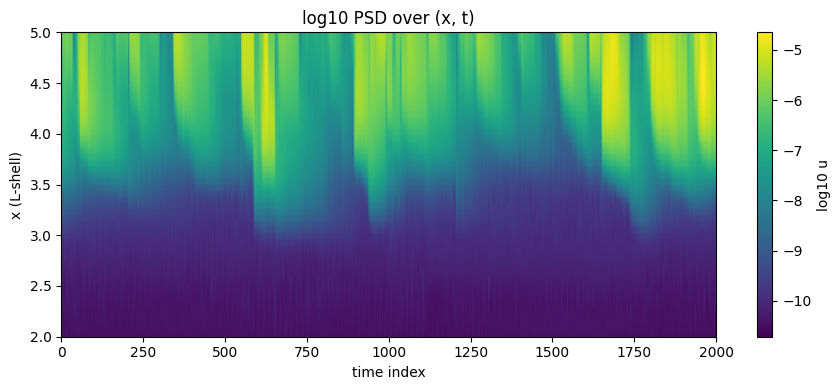

In [2]:
# Load the dataset (Time, Space, PSD)
root_dir = os.getcwd()
data_path = os.path.join(root_dir, "data", "Data_final_project.csv")
assert os.path.exists(data_path), (
    f"Data file not found at: {data_path}\n"
    "Make sure the 'data/' folder is in the same directory as this notebook."
)

# Read the CSV file into a DataFrame and print basic info
df = pd.read_csv(data_path)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
print(df.head())
print("Total rows:", len(df))

# Grid sizes
Nx, Nt = 50, 2000

# Reshape PSD into a (Nx, Nt) matrix
U_data = df["PSD"].to_numpy(dtype=np.float64).reshape(Nx, Nt)
print("U_data shape:", U_data.shape)
print("U_data min/max:", U_data.min(), U_data.max())

# Spatial grid
x = np.linspace(2.0, 5.0, Nx)

# Quick visualization of log10(PSD) over (x, t)
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(np.log10(U_data), aspect="auto", origin="lower",
               extent=[0, Nt, x[0], x[-1]], cmap="viridis")
ax.set_xlabel("time index")
ax.set_ylabel("x (L-shell)")
ax.set_title("log10 PSD over (x, t)")
plt.colorbar(im, ax=ax, label="log10 u")
plt.tight_layout()
plt.show()

2: Define an auxiliary variable T_train in units of days

In [3]:
# Convert each timestamp to days elapsed since the first observation
times = pd.to_datetime(df["Time"].iloc[:Nt], format="%d-%b-%Y %H:%M:%S")
T_train = (times - times.iloc[0]).dt.total_seconds().to_numpy() / 86400.0
T_train = T_train.astype(np.float64)

print("T_train shape:", T_train.shape)
print("T_train range: [{:.4f}, {:.4f}] days".format(T_train.min(), T_train.max()))

# Sanity check: solver expects t = np.linspace(0, 364.0, 2000)
t_solver = np.linspace(0.0, 364.0, Nt)
print("Max |T_train - t_solver| =", np.max(np.abs(T_train - t_solver)))

T_train shape: (2000,)
T_train range: [0.0000, 364.0000] days
Max |T_train - t_solver| = 1.1568284151053376e-05


3: Estimate D(x) using a Physics-Informed Neural Network

In [4]:
# --- Hyperparameters ----------------------------------------------------

# Loss Weights
LAMBDA_DATA = 1.0   # Weight for data fitting loss
LAMBDA_PDE  = 1.0   # Weight on physics-informed loss. Auto-scaled after pre-training
LAMBDA_REG  = 1e-2  # Weight on regularization penalty
LOG_D_FLOOR = -8.0  # Minimum log diffusivity to prevent numerical issues

# Training schedule
PRETRAIN_STEPS = 3000   # Steps where only u_net trains on data loss
JOINT_STEPS    = 10000  # Steps where both u_net and d_net train on combined loss
BATCH_SIZE     = 2048   # (x,t) points sampled per step for the data loss
COLL_BATCH     = 2048   # (x,t) points sampled per step for the PDE residual
LR_PRETRAIN    = 1e-3   # Learning rate for pre-training
LR_JOINT       = 5e-4   # Learning rate for joint training

# Set up the random number generator for reproducibility
rng = np.random.default_rng(SEED)

# Flatten the (x, t, u) data 
x_grid, t_grid = np.meshgrid(x, T_train, indexing="ij")
x_flat    = x_grid.reshape(-1, 1).astype(np.float32)
t_flat    = t_grid.reshape(-1, 1).astype(np.float32)
log_u_flat = np.log(U_data).reshape(-1, 1).astype(np.float32)

# Print dataset statistics
N_total = x_flat.shape[0]
print("Total training points:", N_total)
print("log u range:", float(log_u_flat.min()), float(log_u_flat.max()))

# Convert to TensorFlow tensors
x_tf      = tf.convert_to_tensor(x_flat, dtype=tf.float32)
t_tf      = tf.convert_to_tensor(t_flat, dtype=tf.float32)
log_u_tf  = tf.convert_to_tensor(log_u_flat, dtype=tf.float32)
x_tf_phys = tf.convert_to_tensor(x.reshape(-1, 1).astype(np.float32))

Total training points: 100000
log u range: -24.669374465942383 -10.711427688598633


**3a. Network architectures**: `u_net(x,t)` outputs `log u`, `D_net(x)` outputs `log D` (then `exp` for positivity). Inputs are normalized via `tf.keras.layers.Normalization` (Week-7 style).

In [5]:
# --- u_net: (x, t) -> log u(x, t) ----------------------------------------

#Apply normalization to both x and t inputs.
xt_normalizer = tf.keras.layers.Normalization(axis=-1)
xt_normalizer.adapt(np.column_stack([x_flat.ravel(), t_flat.ravel()]))

# Define the u_net architecture
u_inp = tf.keras.Input(shape=(2,), name="xt")
hu = xt_normalizer(u_inp)
hu = tf.keras.layers.Dense(64, activation="tanh")(hu)
hu = tf.keras.layers.Dense(64, activation="tanh")(hu)
hu = tf.keras.layers.Dense(64, activation="tanh")(hu)
hu = tf.keras.layers.Dense(64, activation="tanh")(hu)
log_u_out = tf.keras.layers.Dense(1)(hu)

# Package into a Keras Model
u_net = tf.keras.Model(u_inp, log_u_out, name="u_net")

# --- d_net: x -> log D(x) -------------------------------------------------

# Apply normalization to x input.
x_normalizer = tf.keras.layers.Normalization(axis=-1)
x_normalizer.adapt(x.reshape(-1, 1).astype(np.float32))

# Define the d_net architecture
d_inp = tf.keras.Input(shape=(1,), name="x")
hd = x_normalizer(d_inp)
hd = tf.keras.layers.Dense(32, activation="tanh")(hd)
hd = tf.keras.layers.Dense(32, activation="tanh")(hd)
hd = tf.keras.layers.Dense(32, activation="tanh")(hd)
log_d_out = tf.keras.layers.Dense(
    1, bias_initializer=tf.keras.initializers.Constant(-2.3))(hd)

# Package into a Keras Model
d_net = tf.keras.Model(d_inp, log_d_out, name="d_net")

# Print model summaries 
u_net.summary()
d_net.summary()

# Test forward passes to check output shapes
sample_log_u = u_net(tf.concat([x_tf[:5], t_tf[:5]], axis=1))
sample_log_d = d_net(x_tf_phys)
print("u_net out shape:", sample_log_u.shape)
print("d_net out shape:", sample_log_d.shape)

Model: "u_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xt (InputLayer)                 │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 2)              │             5 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,742 (49.78 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 5 (24.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ x (InputLayer)                  │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,212 (8.64 KB)

 Trainable params: 2,209 (8.63 KB)

 Non-trainable params: 3 (16.00 B)

u_net out shape: (5, 1)
d_net out shape: (50, 1)


**3b. Loss functions**

- **Data loss** — MSE between `u_net(x,t)` (which is `log u`) and `log U_data`. Working in log space handles the many-orders-of-magnitude range of $u$.
- **PDE residual** — using $v = \log u$, $u_t = u\,v_t$ and $(D u_x)_x = u\,[D' v_x + D(v_x^2 + v_{xx})]$, so the PDE divided by $u$ gives:
  $$ r(x,t) = v_t \;-\; D'(x)\,v_x \;-\; D(x)\,(v_x^2 + v_{xx}) $$
  Using two nested `tf.GradientTape` for the second-order spatial derivative.
- **Regularization** — soft barrier penalty on $\log D$ when it falls below `LOG_D_FLOOR`, preventing the network from collapsing to $D \to 0$.

In [6]:
# Function to compute the PDE residual at a batch of collocation points
def pde_residual(x_b, t_b):
    
    # Combine x and t into a single input for u_net
    xt = tf.concat([x_b, t_b], axis=1)

    # Compute v = log u and its derivatives 
    with tf.GradientTape() as tape2:
        tape2.watch(xt)
        with tf.GradientTape() as tape1:
            tape1.watch(xt)
            v = u_net(xt, training=True)
        grads1 = tape1.gradient(v, xt)   # (N, 2)
        v_x = grads1[:, 0:1]
        v_t = grads1[:, 1:2]
    v_xx = tape2.gradient(v_x, xt)[:, 0:1]

    # Compute derivative of d(x) (derivative of diffusion coefficient)
    with tf.GradientTape() as tape_d:
        tape_d.watch(x_b)
        log_d = d_net(x_b, training=True)
        d_val = tf.exp(log_d)
    d_x = tape_d.gradient(d_val, x_b)

    # Compute residual of PDE
    residual = v_t - d_x * v_x - d_val * (v_x ** 2 + v_xx)
    return residual, d_val, log_d

# Compute loss from all components: data, PDE residual, and regularization
def compute_full_losses(x_b, t_b, log_u_b, x_coll, t_coll, x_phys):

    # Data loss in log space (does u_net match the observations?)
    xt_data = tf.concat([x_b, t_b], axis=1)
    v_data_pred = u_net(xt_data, training=True)
    data_loss = tf.reduce_mean(tf.square(v_data_pred - log_u_b))

    # PDE loss at collocation points (does u_net and d_net satisfy the diffusion equation?)
    residual, _, _ = pde_residual(x_coll, t_coll)
    pde_loss = tf.reduce_mean(tf.square(residual))

    # Regularization (is d(x) positive and not too small?)
    log_d_phys = d_net(x_phys, training=True)
    barrier = tf.nn.relu(LOG_D_FLOOR - log_d_phys)
    reg_loss = tf.reduce_mean(tf.square(barrier))

    # Weighted total loss
    total = LAMBDA_DATA * data_loss + LAMBDA_PDE * pde_loss + LAMBDA_REG * reg_loss
    return total, data_loss, pde_loss, reg_loss

#  Set up optimizers for pre-training and joint training
optimizer_pre   = tf.keras.optimizers.Adam(learning_rate=LR_PRETRAIN)
optimizer_joint = tf.keras.optimizers.Adam(learning_rate=LR_JOINT)

# Function for pre-training u_net on data loss only
@tf.function
def pretrain_step(x_b, t_b, log_u_b):

    # Perform a forward pass and compute the data loss
    with tf.GradientTape() as tape:
        xt = tf.concat([x_b, t_b], axis=1)
        v_pred = u_net(xt, training=True)
        loss = tf.reduce_mean(tf.square(v_pred - log_u_b))

    # Compute gradients and update u_net parameters
    grads = tape.gradient(loss, u_net.trainable_variables)
    optimizer_pre.apply_gradients(zip(grads, u_net.trainable_variables))
    return loss

# Function for joint training of both u_net and d_net on the full PINN loss
def joint_step(x_b, t_b, log_u_b, x_coll, t_coll, x_phys):

    # Combine all weights from both networks for gradient computation
    trainable = u_net.trainable_variables + d_net.trainable_variables

    # Compute the total loss and its components
    with tf.GradientTape() as tape:
        total, data_loss, pde_loss, reg_loss = compute_full_losses(
            x_b, t_b, log_u_b, x_coll, t_coll, x_phys
        )
    
    # Compute gradients and update both u_net and d_net parameters 
    grads = tape.gradient(total, trainable)
    optimizer_joint.apply_gradients(zip(grads, trainable))
    return total, data_loss, pde_loss, reg_loss


# Test initial losses before training
_idx = np.random.choice(N_total, size=128, replace=False)  # Pick 128 random points for a quick loss check
_t, _d, _p, _r = compute_full_losses(
    tf.gather(x_tf, _idx), tf.gather(t_tf, _idx), tf.gather(log_u_tf, _idx),
    tf.gather(x_tf, _idx), tf.gather(t_tf, _idx), x_tf_phys
)
print("Initial total / data / pde / reg:",
      float(_t), float(_d), float(_p), float(_r))

Initial total / data / pde / reg: 383.3453369140625 383.3451843261719 0.0001439237385056913 0.0


**3c. Pre-training** (data loss only). Hint: *"Pre-train on the data loss first before training on the full PINN loss."* This gives `u_net` a sensible representation of `log u(x,t)` so the PDE residual derivatives are meaningful before `D_net` starts adapting.

Pre-training u_net for 3000 steps (data loss only)...
  step     1 | data_loss = 3.8198e+02
  step   500 | data_loss = 1.8110e+00
  step  1000 | data_loss = 1.4214e+00
  step  1500 | data_loss = 1.2611e+00
  step  2000 | data_loss = 1.2328e+00
  step  2500 | data_loss = 1.1808e+00
  step  3000 | data_loss = 1.0672e+00


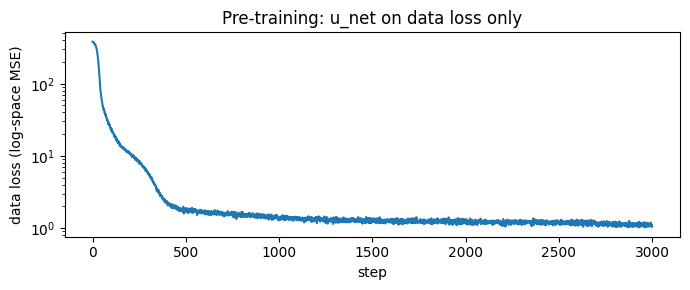


Auto-scaled LAMBDA_PDE = 1.0  (data=1.103e+00, pde=1.114e+01)


In [7]:
#Init list to store loss at each pre-training step
history_pre = []

print(f"Pre-training u_net for {PRETRAIN_STEPS} steps (data loss only)...")

# Run pre-training loop 
for step in range(1, PRETRAIN_STEPS + 1):
    idx = rng.choice(N_total, size=BATCH_SIZE, replace=False) # Sample a random batch of data points for this step
    loss = pretrain_step(
        tf.gather(x_tf, idx),
        tf.gather(t_tf, idx),
        tf.gather(log_u_tf, idx),
    ) 
    history_pre.append(float(loss))

    # Print progress every 500 steps
    if step % 500 == 0 or step == 1:
        print(f"  step {step:5d} | data_loss = {history_pre[-1]:.4e}")

# Create a plot of the pre-training data loss over steps (log scale)
plt.figure(figsize=(7, 3))
plt.plot(history_pre)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("data loss (log-space MSE)")
plt.title("Pre-training: u_net on data loss only")
plt.tight_layout()
plt.show()

# Apply auto-scaling to LAMBDA_PDE based on the initial magnitudes of data and PDE losses
idx_s = rng.choice(N_total, size=4096, replace=False)
_, data_check, pde_check, _ = compute_full_losses(
    tf.gather(x_tf, idx_s), tf.gather(t_tf, idx_s), tf.gather(log_u_tf, idx_s),
    tf.gather(x_tf, idx_s), tf.gather(t_tf, idx_s), x_tf_phys)

#Set LAMBDA_PDE to the ratio of data loss to PDE loss, ensuring it's at least 1.0 to prevent underweighting the PDE loss.
LAMBDA_PDE = max(1.0, float(data_check) / (float(pde_check) + 1e-8))
print(f"\nAuto-scaled LAMBDA_PDE = {LAMBDA_PDE:.1f}  "
      f"(data={float(data_check):.3e}, pde={float(pde_check):.3e})")

**3d. Joint training** on the full PINN loss = `data + PDE + reg`. Both `u_net` and `D_net` are updated. Mini-batches are sampled randomly each step (data and collocation independently).

Joint training for 10000 steps (data + PDE + reg)...
  step     1 | total=1.1381e+01  data=1.0846e+00  pde=1.0297e+01  reg=0.0000e+00
  step   500 | total=1.1007e+00  data=1.0982e+00  pde=2.5644e-03  reg=0.0000e+00
  step  1000 | total=1.0669e+00  data=1.0655e+00  pde=1.4341e-03  reg=0.0000e+00
  step  1500 | total=8.6967e-01  data=8.6801e-01  pde=1.6652e-03  reg=0.0000e+00
  step  2000 | total=7.0046e-01  data=6.9634e-01  pde=4.1176e-03  reg=0.0000e+00
  step  2500 | total=6.7057e-01  data=6.6518e-01  pde=5.3912e-03  reg=2.6676e-04
  step  3000 | total=6.6292e-01  data=6.5720e-01  pde=5.7175e-03  reg=6.4898e-04
  step  3500 | total=7.2055e-01  data=7.1371e-01  pde=6.8373e-03  reg=3.7438e-04
  step  4000 | total=6.9275e-01  data=6.8521e-01  pde=7.5451e-03  reg=1.4590e-04
  step  4500 | total=6.0012e-01  data=5.9295e-01  pde=7.1698e-03  reg=6.0791e-05
  step  5000 | total=5.2841e-01  data=5.2087e-01  pde=7.5447e-03  reg=0.0000e+00
  step  5500 | total=5.0438e-01  data=4.9562e-01  pde=8.

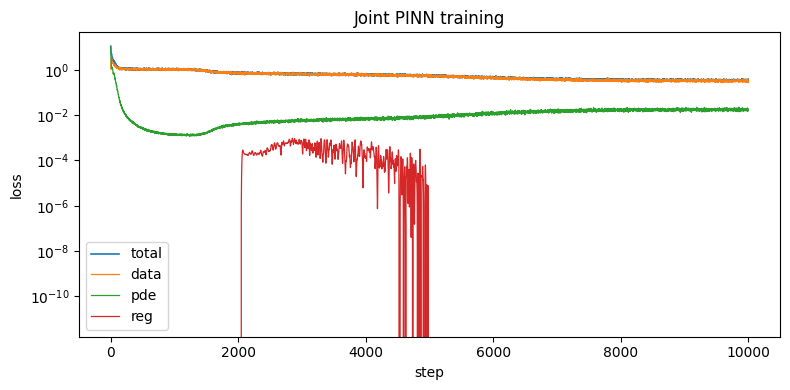

In [8]:
# Create a dictionary to store the loss history during joint training
history_joint = {"total": [], "data": [], "pde": [], "reg": []}

print(f"Joint training for {JOINT_STEPS} steps (data + PDE + reg)...")

# Run joint training loop
for step in range(1, JOINT_STEPS + 1):

    # Apply LR decay in the final 2000 steps for finer convergence
    if step == JOINT_STEPS - 2000:
        optimizer_joint.learning_rate.assign(1e-4)
        print(f"  step {step}: LR -> 1e-4")

    # Create 2 independent random batches: one for data loss and one for PDE residuals
    idx_d = rng.choice(N_total, size=BATCH_SIZE, replace=False)
    idx_c = rng.choice(N_total, size=COLL_BATCH, replace=False)

    # Perform a joint training step
    total, data_loss, pde_loss, reg_loss = joint_step(
        tf.gather(x_tf, idx_d), tf.gather(t_tf, idx_d), tf.gather(log_u_tf, idx_d),
        tf.gather(x_tf, idx_c), tf.gather(t_tf, idx_c),
        x_tf_phys,
    )

    # Record the losses for plotting
    history_joint["total"].append(float(total))
    history_joint["data"].append(float(data_loss))
    history_joint["pde"].append(float(pde_loss))
    history_joint["reg"].append(float(reg_loss))

    # Print progress every 500 steps
    if step % 500 == 0 or step == 1:
        print(f"  step {step:5d} | total={float(total):.4e}  "
              f"data={float(data_loss):.4e}  pde={float(pde_loss):.4e}  "
              f"reg={float(reg_loss):.4e}")

# Plot all 4 loss components over the joint training steps on a log scale
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_joint["total"], label="total", lw=1.2)
ax.plot(history_joint["data"], label="data", lw=0.9)
ax.plot(history_joint["pde"],  label="pde",  lw=0.9)
ax.plot(history_joint["reg"],  label="reg",  lw=0.9)
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Joint PINN training")
ax.legend()
plt.tight_layout()
plt.show()

**3e. Inspect the learned solution**: compare `u_net` reconstruction against the data, sanity-check that we haven't just memorized.

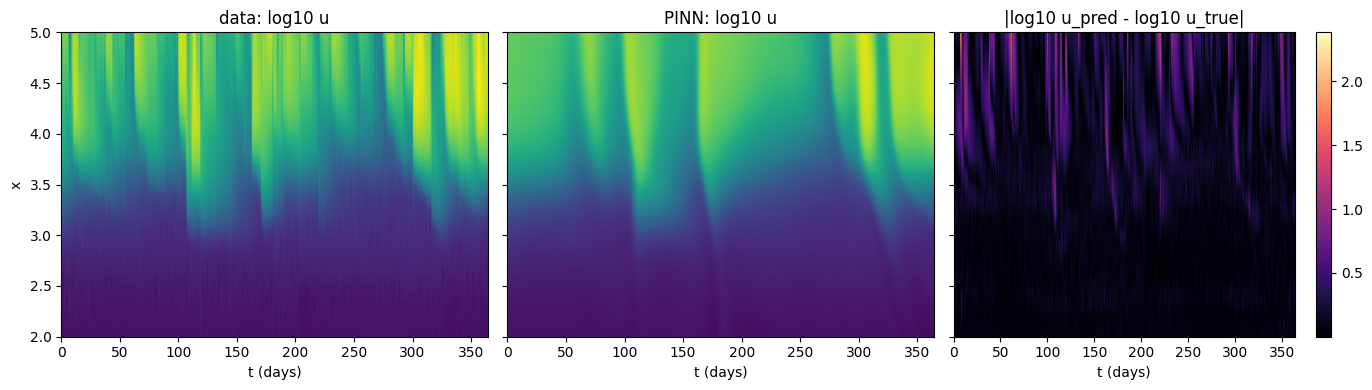

Mean |log10 error|: 0.1669165083644064
Max  |log10 error|: 2.3846771771215893


In [9]:
# Get the final predictions of log u(x,t) on the full grid after training
log_u_pred = u_net(tf.concat([x_tf, t_tf], axis=1), training=False).numpy()
log_u_pred = log_u_pred.reshape(Nx, Nt)
log_u_true = np.log(U_data)

# Create plot of 3 side by side heatmaps: log10 u from data, log10 u from PINN, and their absolute error
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
vmin = np.log10(U_data).min()
vmax = np.log10(U_data).max()

axes[0].imshow(np.log10(U_data), aspect="auto", origin="lower",
               extent=[T_train[0], T_train[-1], x[0], x[-1]],
               vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("data: log10 u")
axes[0].set_xlabel("t (days)"); axes[0].set_ylabel("x")

axes[1].imshow(log_u_pred / np.log(10), aspect="auto", origin="lower",
               extent=[T_train[0], T_train[-1], x[0], x[-1]],
               vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("PINN: log10 u")
axes[1].set_xlabel("t (days)")

err = np.abs(log_u_pred - log_u_true) / np.log(10)
im = axes[2].imshow(err, aspect="auto", origin="lower",
                    extent=[T_train[0], T_train[-1], x[0], x[-1]], cmap="magma")
axes[2].set_title("|log10 u_pred - log10 u_true|")
axes[2].set_xlabel("t (days)")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()

print("Mean |log10 error|:", float(err.mean()))
print("Max  |log10 error|:", float(err.max()))

4: After training the PINN use the learned coefficient in a numerical solver for the ODE

my_D_prediction shape: (50, 1)
d(x) min/max: 0.0003924302873201668 0.029041925445199013


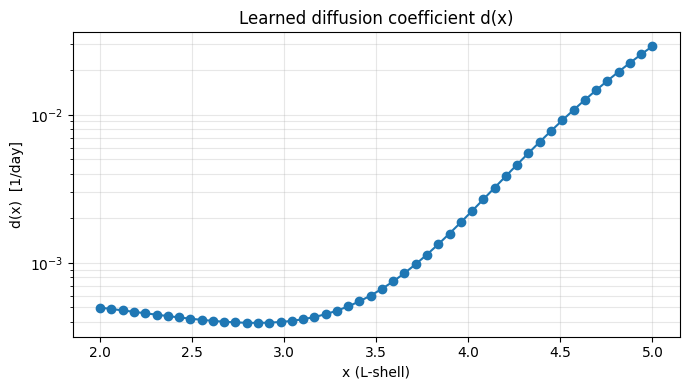

In [10]:
# Extract the learned diffusion coefficient d(x) on the x grid
log_d_grid = d_net(x_tf_phys, training=False).numpy()
d_grid = np.exp(log_d_grid)             # shape (Nx, 1)

# Array passed to the grader / solver
my_D_prediction = d_grid.astype(np.float64).reshape(Nx, 1)
print("my_D_prediction shape:", my_D_prediction.shape)
print("d(x) min/max:", float(my_D_prediction.min()), float(my_D_prediction.max()))

# Create a plot of the learned diffusion coefficient d(x) vs x on a log scale
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, my_D_prediction.ravel(), "o-", lw=1.5)
ax.set_yscale("log")
ax.set_xlabel("x (L-shell)")
ax.set_ylabel("d(x)  [1/day]")
ax.set_title("Learned diffusion coefficient d(x)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

5: Save prediction & test score (provided grader cell)

In [11]:
## Function to solve numerically the ODE

def crank_nicolson_diffusion(D, u_initial, bc_bottom, bc_top):
    """
    Solves the 1D diffusion equation using the second-order Crank-Nicholson method.

    PDE: u_t  =  (D(x,t)*u_x)_x
    """
        # Discretization
    Nx, Nt = 50, 2000
    x = np.linspace(2,5,Nx)
    t = np.linspace(0,364.0,Nt)

    dx = x[1] - x[0]
    dt = t[1] - t[0]

    u = np.zeros((Nx, Nt))
    u[:,0] = u_initial
    D = np.array(D[:,0])
    D_half = 0.5*(D[0:-1]+D[1:])

    alpha = D_half[0:] / dx**2
    beta = 2* D[1:Nx] / dx**2
    gamma = D_half[1:] / dx**2

    A_upper = -0.5 * dt* gamma
    A_diag = 1 + 0.5 * dt* beta
    A_lower = -0.5 * dt* alpha

    B_upper = 0.5 * dt*gamma
    B_diag = 1 - 0.5 * dt*beta
    B_lower = 0.5 * dt*alpha

    A_banded = np.zeros((3, Nx))
    A_banded[0, 2:] = A_upper
    A_banded[1, 1:] = A_diag
    A_banded[2, :-1] = A_lower

    A_banded[1,0]=1
    A_banded[0,1]=0
    A_banded[1,-1]=1
    A_banded[2,-2]=0

    for n in range(0, Nt - 1):
        rhs = np.zeros(Nx)
        for i in range(1, Nx - 1):
            rhs[i] = (B_lower[i] * u[i - 1, n] +
                      B_diag[i] * u[i, n] +
                      B_upper[i-1] * u[i + 1, n])
        rhs[0] = U_BC_bottom[n + 1]
        rhs[-1] = U_BC_top[n + 1]
        u[:, n + 1] = solve_banded((1, 1), A_banded, rhs)

    return x, t, u


# Ground truth and boundary conditions
U_truth    = df['PSD'].to_numpy().reshape(50, 2000)
U_initial  = df['PSD'].to_numpy().reshape(50, 2000)[:, 0]
U_BC_bottom = df['PSD'].to_numpy().reshape(50, 2000)[0, :]
U_BC_top   = df['PSD'].to_numpy().reshape(50, 2000)[-1, :]

Nx = 50
x = np.linspace(2, 5, Nx)

# my_D_prediction was produced by d_net in step 4 (numpy array of shape (Nx, 1))
np.savetxt("LAZOS_my_D.csv", my_D_prediction, delimiter=",")
print("Saved LAZOS_my_D.csv to:", os.path.join(os.getcwd(), "LAZOS_my_D.csv"))

x, t, u = crank_nicolson_diffusion(my_D_prediction, U_initial, U_BC_bottom, U_BC_top)

score = min(0.1/np.mean(np.abs( (np.log10(u) - np.log10(U_truth))/np.log(U_truth))),1.0)*100
print('My score = ', score)

Saved LAZOS_my_D.csv to: c:\Users\miste\OneDrive\Desktop\Msc AI and Machine Learning\AI in Astrophysics and Space Science\finalproject\LAZOS_my_D.csv
My score =  100.0


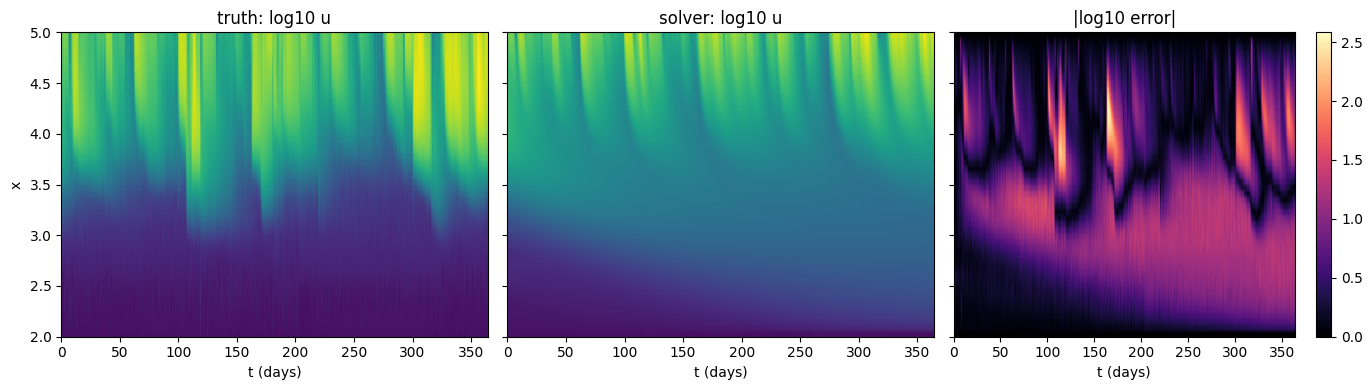

In [12]:
# Visual sanity check
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
vmin = np.log10(U_truth).min(); vmax = np.log10(U_truth).max()
axes[0].imshow(np.log10(U_truth), aspect="auto", origin="lower",
               extent=[t[0], t[-1], x[0], x[-1]], vmin=vmin, vmax=vmax, cmap="viridis")
axes[0].set_title("truth: log10 u"); axes[0].set_xlabel("t (days)"); axes[0].set_ylabel("x")
axes[1].imshow(np.log10(np.maximum(u, 1e-30)), aspect="auto", origin="lower",
               extent=[t[0], t[-1], x[0], x[-1]], vmin=vmin, vmax=vmax, cmap="viridis")
axes[1].set_title("solver: log10 u"); axes[1].set_xlabel("t (days)")
err = np.abs(np.log10(u) - np.log10(U_truth))
im = axes[2].imshow(err, aspect="auto", origin="lower",
                    extent=[t[0], t[-1], x[0], x[-1]], cmap="magma")
axes[2].set_title("|log10 error|"); axes[2].set_xlabel("t (days)")
plt.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()